# py-URD — R parity validation

Flood-pseudotime on Guo et al. 2010 qPCR fixture (428 cells × 48 genes).

## 1. Setup

In [1]:
import os, json, sys, subprocess
for k in ('OMP_NUM_THREADS','OPENBLAS_NUM_THREADS','MKL_NUM_THREADS'): os.environ[k]='8'
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import yaml
NB = Path('.').resolve(); PORT = NB.parent if NB.name=='examples' else NB
sys.path.insert(0, str(PORT)); sys.path.insert(0, str(PORT.parent/'omicverse-rebuildr'/'engine'))
from parity_metrics import compute_parity
manifest = yaml.safe_load((PORT/'data'/'manifest.yaml').read_text())
print(f"Port: {manifest['package']}, upstream: URD v{manifest['upstream']['version']}")
for o in manifest['outputs']:
    print(f"  {o['name']:18s} {o['metric']:12s} >= {o['threshold']}")

Port: pyurd, upstream: URD v1.1.1
  pseudotime         spearman     >= 0.8


## 2-3. R + Py runs

In [2]:
R_ENV=os.environ.get('R_TEST_ENV','/scratch/users/steorra/env/CMAP')
subprocess.run(['conda','run','-p',R_ENV,'Rscript',str(PORT/manifest['reference_command']),
                str(PORT/manifest['fixture']['path']), str(PORT/'data'/'reference_output.json')],
               check=True, cwd=PORT, capture_output=True)
subprocess.run(['python', str(PORT/'tests'/'_run_candidate.py'),
                str(PORT/manifest['fixture']['path']), str(PORT/'data'/'candidate_output.json')],
               check=True, cwd=PORT, capture_output=True)
ref = json.loads((PORT/'data'/'reference_output.json').read_text())
cand = json.loads((PORT/'data'/'candidate_output.json').read_text())
print('R + Py ran')

R + Py ran


## 4. Per-output parity

### 4.1 Pseudotime (Spearman + Pearson)

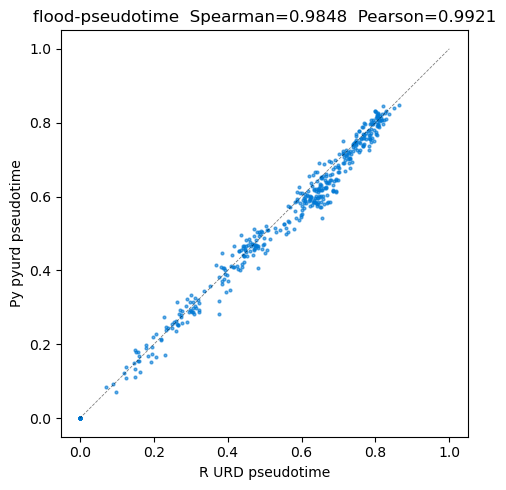

PASS  threshold=0.8  measured=0.9848


In [3]:
def to_arr(xs): return np.array([np.nan if x is None else float(x) for x in xs])
pt_r = to_arr(ref['pseudotime']); pt_p = to_arr(cand['pseudotime'])
mask = ~np.isnan(pt_r) & ~np.isnan(pt_p)
from scipy.stats import spearmanr, pearsonr
rho = spearmanr(pt_r[mask], pt_p[mask])[0]
pe  = pearsonr(pt_r[mask], pt_p[mask])[0]
fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(pt_r[mask], pt_p[mask], s=4, alpha=0.6, c='#0078d4')
ax.plot([0,1],[0,1],'k--',lw=0.6,alpha=0.5)
ax.set_xlabel('R URD pseudotime'); ax.set_ylabel('Py pyurd pseudotime')
ax.set_title(f'flood-pseudotime  Spearman={rho:.4f}  Pearson={pe:.4f}')
ax.set_aspect('equal'); plt.tight_layout(); plt.show()
spec = next(o for o in manifest['outputs'] if o['name']=='pseudotime')
print(f"{'PASS' if rho >= spec['threshold'] else 'FAIL'}  threshold={spec['threshold']}  measured={rho:.4f}")

### 4.2 Histogram comparison

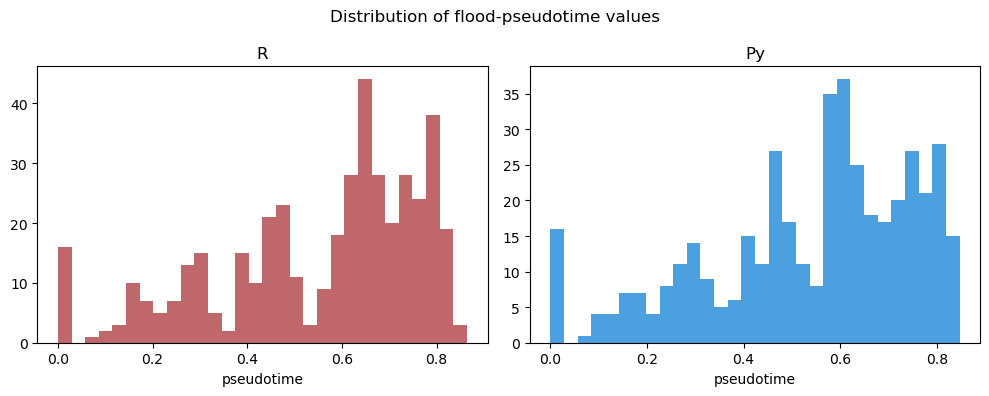

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10,4))
a1.hist(pt_r[mask], bins=30, color='#a4262c', alpha=0.7); a1.set_title('R')
a2.hist(pt_p[mask], bins=30, color='#0078d4', alpha=0.7); a2.set_title('Py')
for a in (a1, a2): a.set_xlabel('pseudotime')
plt.suptitle('Distribution of flood-pseudotime values')
plt.tight_layout(); plt.show()

## 5. Verdict

In [5]:
from scipy.stats import spearmanr
pt_r = to_arr(ref['pseudotime']); pt_p = to_arr(cand['pseudotime'])
mask = ~np.isnan(pt_r) & ~np.isnan(pt_p)
rho = spearmanr(pt_r[mask], pt_p[mask])[0]
spec = next(o for o in manifest['outputs'] if o['name']=='pseudotime')
print('='*70)
print(f"  {'PASS' if rho >= spec['threshold'] else 'FAIL'}  pseudotime Spearman  threshold={spec['threshold']}  measured={rho:.4f}")
print(f"  cells with non-NA pseudotime: R={int((~np.isnan(pt_r)).sum())}, Py={int((~np.isnan(pt_p)).sum())}")
print('='*70)
print('OVERALL: ' + ('PASS' if rho >= spec['threshold'] else 'FAIL'))

  PASS  pseudotime Spearman  threshold=0.8  measured=0.9848
  cells with non-NA pseudotime: R=428, Py=428
OVERALL: PASS
